In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

!pip install xgboost
import joblib

In [2]:
import xgboost as xgb

In [3]:
df = pd.read_csv("data_ML.csv")
print(df)

      Employee_ID            Name  Age  Gender   Department  Job_Title  \
0               1    Merle Ingram   24  Female  Engineering   Engineer   
1               2      John Mayes   56    Male        Sales  Executive   
2               3    Carlos Wille   21    Male  Engineering     Intern   
3               4  Michael Bryant   30    Male      Finance    Analyst   
4               5   Paula Douglas   25  Female           HR    Analyst   
...           ...             ...  ...     ...          ...        ...   
9995         9996   Thomas Rossin   51    Male        Sales  Executive   
9996         9997   Christie King   36  Female        Sales  Executive   
9997         9998   Alfred Keller   57    Male        Sales  Executive   
9998         9999  Margaret Gomez   37  Female  Engineering    Manager   
9999        10000   Joan Sorensen   25  Female        Sales    Analyst   

      Experience_Years Education_Level       Location  Salary  
0                    1          Master         

In [4]:
df.head()

,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,1,Merle Ingram,24,Female,Engineering,Engineer,1,Master,Austin,90000
1,2,John Mayes,56,Male,Sales,Executive,33,Master,Seattle,195000
2,3,Carlos Wille,21,Male,Engineering,Intern,1,Bachelor,New York,35000
3,4,Michael Bryant,30,Male,Finance,Analyst,9,Bachelor,New York,75000
4,5,Paula Douglas,25,Female,HR,Analyst,2,Master,Seattle,70000


In [5]:
df.tail()

,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
9995,9996,Thomas Rossin,51,Male,Sales,Executive,28,Master,Austin,185000
9996,9997,Christie King,36,Female,Sales,Executive,9,PhD,San Francisco,165000
9997,9998,Alfred Keller,57,Male,Sales,Executive,30,PhD,New York,200000
9998,9999,Margaret Gomez,37,Female,Engineering,Manager,14,Master,New York,135000
9999,10000,Joan Sorensen,25,Female,Sales,Analyst,4,Bachelor,San Francisco,70000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Employee_ID       10000 non-null  int64 
 1   Name              10000 non-null  object
 2   Age               10000 non-null  int64 
 3   Gender            10000 non-null  object
 4   Department        10000 non-null  object
 5   Job_Title         10000 non-null  object
 6   Experience_Years  10000 non-null  int64 
 7   Education_Level   10000 non-null  object
 8   Location          10000 non-null  object
 9   Salary            10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


In [7]:
df.describe()

,Employee_ID,Age,Experience_Years,Salary
count,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,35.455900,12.370900,115381.500000
std,2886.89568,10.000213,9.148951,46066.139047
min,1.00000,21.000000,0.000000,25000.000000
25%,2500.75000,27.000000,5.000000,70000.000000
50%,5000.50000,34.000000,10.000000,120000.000000
75%,7500.25000,43.000000,19.000000,150000.000000
max,10000.00000,60.000000,37.000000,215000.000000


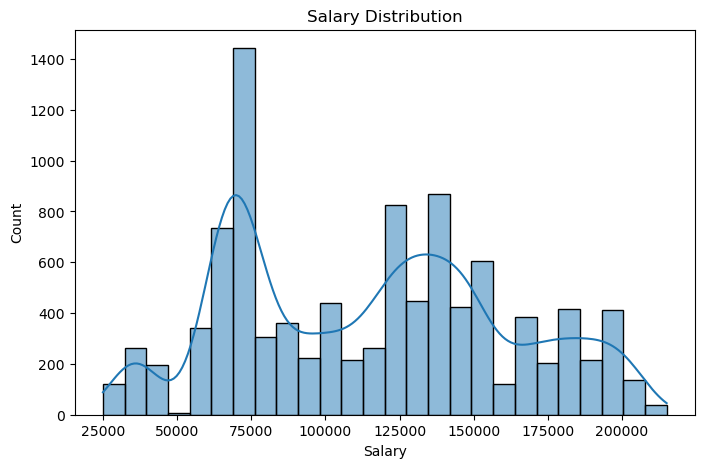

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["Salary"], kde=True)
plt.title("Salary Distribution")
plt.show()

In [9]:
df["Salary"].skew()

np.float64(0.14510089316802435)

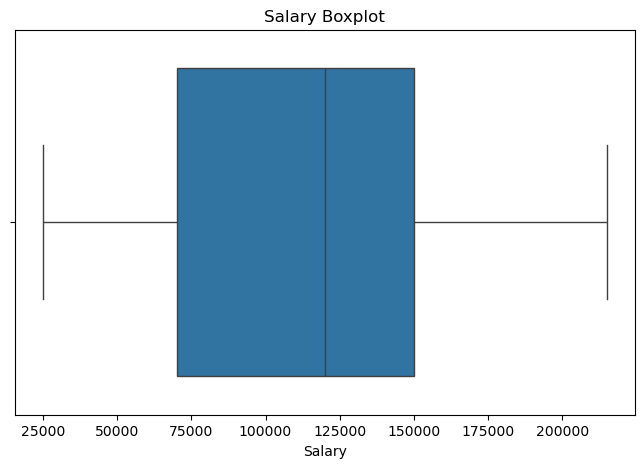

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Salary"])
plt.title("Salary Boxplot")
plt.show()

In [11]:
df = df.drop(["Employee_ID", "Name"], axis=1)
df.head()

,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,24,Female,Engineering,Engineer,1,Master,Austin,90000
1,56,Male,Sales,Executive,33,Master,Seattle,195000
2,21,Male,Engineering,Intern,1,Bachelor,New York,35000
3,30,Male,Finance,Analyst,9,Bachelor,New York,75000
4,25,Female,HR,Analyst,2,Master,Seattle,70000


In [12]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,Age,Experience_Years,Salary,Gender_Male,Department_Finance,Department_HR,Department_Marketing,Department_Product,Department_Sales,Job_Title_Engineer,Job_Title_Executive,Job_Title_Intern,Job_Title_Manager,Education_Level_Master,Education_Level_PhD,Location_Chicago,Location_New York,Location_San Francisco,Location_Seattle
0,24,1,90000,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
1,56,33,195000,True,False,False,False,False,True,False,True,False,False,True,False,False,False,False,True
2,21,1,35000,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
3,30,9,75000,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,25,2,70000,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     10000 non-null  int64
 1   Experience_Years        10000 non-null  int64
 2   Salary                  10000 non-null  int64
 3   Gender_Male             10000 non-null  bool 
 4   Department_Finance      10000 non-null  bool 
 5   Department_HR           10000 non-null  bool 
 6   Department_Marketing    10000 non-null  bool 
 7   Department_Product      10000 non-null  bool 
 8   Department_Sales        10000 non-null  bool 
 9   Job_Title_Engineer      10000 non-null  bool 
 10  Job_Title_Executive     10000 non-null  bool 
 11  Job_Title_Intern        10000 non-null  bool 
 12  Job_Title_Manager       10000 non-null  bool 
 13  Education_Level_Master  10000 non-null  bool 
 14  Education_Level_PhD     10000 non-null  bool 
 15  Location_Chicago    

In [14]:
df = df.astype(int)
df.head()

,Age,Experience_Years,Salary,Gender_Male,Department_Finance,Department_HR,Department_Marketing,Department_Product,Department_Sales,Job_Title_Engineer,Job_Title_Executive,Job_Title_Intern,Job_Title_Manager,Education_Level_Master,Education_Level_PhD,Location_Chicago,Location_New York,Location_San Francisco,Location_Seattle
0,24,1,90000,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0
1,56,33,195000,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,1
2,21,1,35000,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0
3,30,9,75000,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,25,2,70000,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1


In [15]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (8000, 18)
Testing set size: (2000, 18)


In [17]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [18]:
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 4168.335593686903
Linear Regression R2: 0.9917562580370475


In [19]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [20]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 4928.193965515387
Random Forest R2: 0.9884767596351964


In [21]:
xgb_model = xgb.XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [22]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R2:", r2_xgb)

XGBoost RMSE: 4551.320687448864
XGBoost R2: 0.9901717901229858


In [23]:
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")

print("Cross-Validation R2 Scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

Cross-Validation R2 Scores: [0.99185086 0.99140357 0.9910836  0.9913755  0.9914439 ]
Average CV R2: 0.991431488027153


In [24]:
# Get coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

# Sort by absolute impact
coefficients["Abs_Coefficient"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values(by="Abs_Coefficient", ascending=False)

coefficients.head(10)

,Feature,Coefficient,Abs_Coefficient
9,Job_Title_Executive,75091.010816,75091.010816
11,Job_Title_Manager,40131.370481,40131.370481
10,Job_Title_Intern,-25975.226503,25975.226503
8,Job_Title_Engineer,19855.674807,19855.674807
13,Education_Level_PhD,9272.593811,9272.593811
12,Education_Level_Master,4692.868684,4692.868684
1,Experience_Years,1664.612002,1664.612002
4,Department_HR,-623.041975,623.041975
5,Department_Marketing,-363.495744,363.495744
6,Department_Product,-332.350550,332.350550


In [25]:
joblib.dump(lr, "salary_prediction_model.pkl")

['salary_prediction_model.pkl']

In [26]:
# Load the saved model
loaded_model = joblib.load("salary_prediction_model.pkl")

In [27]:
sample = X_test.iloc[[0]]
loaded_model.predict(sample)

array([137590.98578821])

In [28]:
print("Predicted Salary:", loaded_model.predict(sample)[0])
print("Actual Salary:", y_test.iloc[0])

Predicted Salary: 137590.98578820826
Actual Salary: 135000


In [29]:
pip install streamlit